# API
---

* Application Programming Interface
* Es una interfaz que permite que dos sistemas se comuniquen entre sí (aplicaciones web, servicios, backend-backend, etc.)

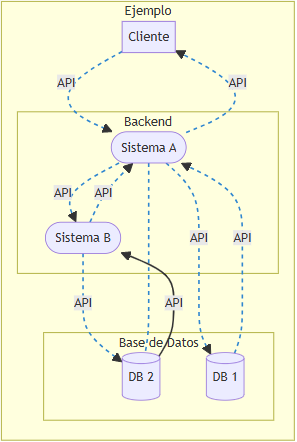

## Tipos de APIs

* Existen diferentes tipos de APIs dependiendo de las características que posean:
    * WebService (WS)
    * Conexiones a las Bases de Datos
    * Interacciones con el Sistema Operativo
    * Etc.

* Los WS tienen la característica de ser APIs que se usan vía internet
* Debido a ello, son los utilizados para interactuar con aplicaciones web
* Dentro de los WebService, los más comunes son los: 
    * SOAP
    * REST

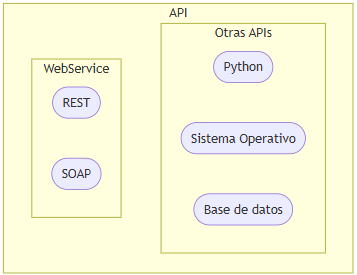

## Comparación entre API REST y API SOAP

| Característica	  | API REST	                                | API SOAP                                |
| --                  | --                                          | --                                      |
| Significado         | Representational State Transfer             | Simple Object Access Protocol           |
| Formato de datos	  | Generalmente JSON (también XML, YAML, etc.) | Exclusivamente XML                      |
| Operaciones típicas |	GET, POST, PUT, DELETE	                    | Métodos definidos por el servicio (RPC) |
| Ejemplo de llamada  |	GET https://api.ejemplo.com/usuarios/1	    | <soap:Envelope>...</soap:Envelope>      |

## Estructura de un WS-REST

* Endpoint: https://abm.arquitectura.dqs.afip.gob.ar/abm/api/agenda?id=1234
    * **Service**: https://abm.arquitectura.dqs.afip.gob.ar/abm/api
    * **Resource**: /agenda
    * **Parameters**: ?id=1234
    * **Method**: GET, POST, PUT, DELETE, etc
    * **Header**: autenticación, tipo de contenido (content_type)
    * **Body**: puede ser JSON o XML (los mas comunes)

## Métodos HTTP

| Verbo	 | Función	              | Ejemplo        |
| --     | --                     | --             |
| GET	 | Obtener datos	      | GET /agenda    |
| POST	 | Crear recurso	      | POST /agenda   |
| PUT	 | Reemplazar recurso     |	PUT /agenda    |
| PATCH	 | Modificar parcialmente |	PATCH /agenda  |
| DELETE | Eliminar recurso	      | DELETE /agenda |

## Estructura de un WS-SOAP

* Endpoint: https://abm.arquitectura.dqs.afip.gob.ar/abm/ws/AgendaService
    * **Servicio**: https://abm.arquitectura.dqs.afip.gob.ar/abm/ws
    * **Resource**: AgendaService
    * **Method**: POST
    * **Header**: Content-Type: text/xml
    * **Body**: el mensaje se envía en formato XML dentro de un envelope SOAP

## Status code

| Código | Significado  |
| --     | --           |
| 200    | OK           |
| 201	 | Created      |
| 400	 | Bad Request  |
| 401    | Unauthorized |
| 404    | Not Found    |
| 500    | Server Error |

## Posibles puntos a ser testeados

* Status code esperado
* Información obtenida en la respuesta sea la esperada
* Estructura de la respuesta sea la esperada
* Tiempo de respuesta
* Reglas de negocio
* Impacto sobre la base de datos
* Etc. 

## Ejemplo API del Servicio de Normalización de Datos Geográficos

* [API del Servicio de Normalización de Datos Geográficos](https://datosgobar.github.io/georef-ar-api/)
* [Libreria requests](https://realpython.com/python-requests/)

In [12]:
%%file api01.py 
import pytest
import requests

def test_geo_ref_ubicacion():
    params = {
    'lat': '-27.2741',
    'lon': '-66.7529'
    }
    response = requests.get('https://apis.datos.gob.ar/georef/api/ubicacion', params=params)
    assert response.status_code == 200
    assert response.json()['ubicacion']['departamento']['nombre'] == 'Belén'

Overwriting api01.py


In [13]:
!pytest api01.py

============================= test session starts ==============================
platform darwin -- Python 3.12.7, pytest-7.4.4, pluggy-1.0.0
rootdir: /Users/ppando/Materias/qa/doc
plugins: allure-pytest-2.16.0, Faker-37.3.0, mock-3.14.1, typeguard-4.4.4, anyio-4.2.0
collected 1 item                                                               

api01.py .                                                               [100%]

============================== 1 passed in 0.25s ===============================


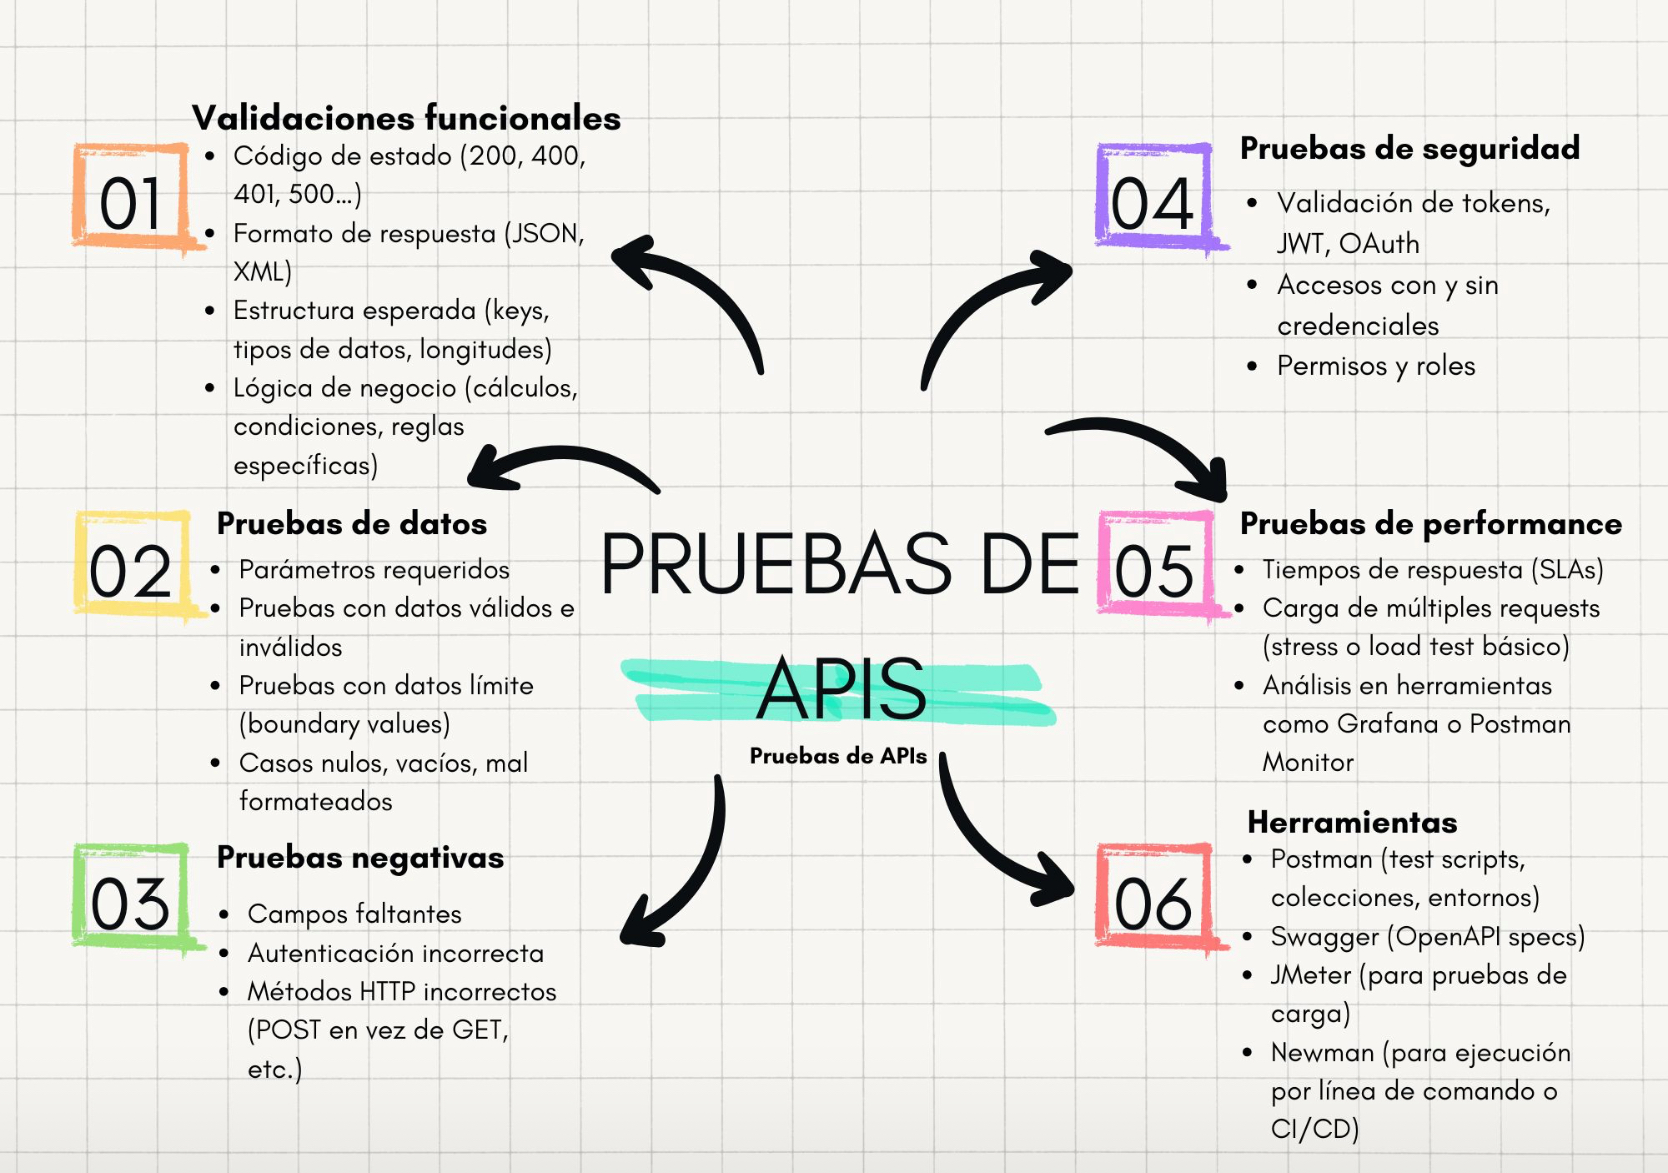